<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 14</span></h2>
<h2><span style="color: #1F77B4; font-size: 50px">Détection d'anomalies</span></h2>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte et permet de régénérer les figures associées selon les conventions graphiques du livre. Deux fils conducteurs se répondent : un nuage synthétique bidimensionnel, qui donne l'intuition visuelle des cinq premières familles de méthodes, et le jeu de données <i>Breast Cancer</i>, utilisé pour illustrer la sixième famille, fondée sur la reconstruction, puis pour comparer les six familles. Le carnet couvre également l'évaluation par les courbes précision-rappel et ROC, les anomalies contextuelles et collectives, ainsi que l'explication SHAP d'un score d'isolation. Les cellules doivent être exécutées séquentiellement, car certaines réutilisent des variables ou des résultats définis en amont.

**Bibliothèques requises** : `numpy`, `pandas`, `matplotlib`, `scikit-learn` (≥ 1.6) et `shap`.  
**Installation complémentaire** : SHAP s'installe avec `pip install shap`.  
**Données externes** : aucun fichier externe n'est nécessaire ; les jeux de données sont générés dans le notebook ou fournis par `scikit-learn`.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PAQUETS = ('numpy', 'pandas', 'matplotlib', 'scikit-learn', 'shap')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'font.size': 13,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Couleurs du livre (palette viridis)
VIOLET, SARCELLE, VERT, BLEU, MAGENTA = '#482878', '#21918c', '#5ec962', '#3b528b', '#bf00bf'
BORD    = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b', MAGENTA: '#8a008a'}
PALETTE = [VIOLET, SARCELLE, VERT, BLEU, MAGENTA]

python             3.12.13
numpy              2.5.1
pandas             3.0.3
matplotlib         3.11.0
scikit-learn       1.9.0
shap               0.52.0


In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 14.1 : Nuage synthétique : deux amas et quinze points épars</h3>

In [3]:
from sklearn.datasets import make_blobs

rng = np.random.default_rng(42)

# Deux amas de densités différentes
X, _ = make_blobs(n_samples=300, centers=[[0, 0], [4, 4]],
                  cluster_std=[0.6, 1.1], random_state=42)

# Quinze points épars, tirés à l'écart des deux amas
centres = np.array([[0, 0], [4, 4]])
anomalies = []
while len(anomalies) < 15:
    p = rng.uniform(-4, 9, 2)
    if np.min(np.linalg.norm(centres - p, axis=1)) > 3.5:
        anomalies.append(p)

X2 = np.vstack([X, np.array(anomalies)])
vrai = np.r_[np.zeros(len(X)), np.ones(15)].astype(int)
print("Observations :", X2.shape[0], "dont", vrai.sum(), "anomalies")

Observations : 315 dont 15 anomalies


<h3><span style="font-size: 30px">&#127924;</span> Figure : Le nuage synthétique et sa zone de rejet</h3>

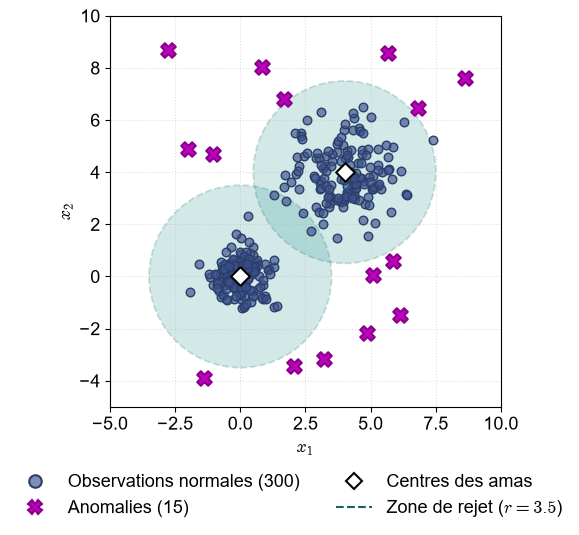

In [4]:
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

fig, ax = plt.subplots(figsize=(7, 5.6))

# Zone de rejet du tirage : disques de rayon 3.5 autour des deux centres
for c in centres:
    ax.add_patch(plt.Circle(c, 3.5, facecolor=SARCELLE, alpha=0.2,
                            edgecolor=BORD[SARCELLE], linestyle='--',
                            linewidth=1.3, zorder=1))

ax.scatter(X2[vrai == 0, 0], X2[vrai == 0, 1], s=38,
           color=to_rgba(BLEU, 0.65), edgecolors=BORD[BLEU],
           linewidths=1.0, zorder=3)
ax.scatter(X2[vrai == 1, 0], X2[vrai == 1, 1], s=110, color=MAGENTA,
           marker='X', edgecolors=BORD[MAGENTA], linewidths=1.5, zorder=4)
ax.scatter(centres[:, 0], centres[:, 1], s=90, marker='D', color='white',
           edgecolors='black', linewidths=1.5, zorder=5)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(-5, 10)
ax.set_ylim(-5, 10)
ax.set_aspect('equal')
ax.grid(alpha=0.4, linestyle=':', zorder=0)

ax.legend(handles=[
    Line2D([], [], marker='o', ls='', color=to_rgba(BLEU, 0.65),
           markeredgecolor=BORD[BLEU],
           label='Observations normales (300)', markersize=9,
           markeredgewidth=1.5),
    Line2D([], [], marker='X', ls='', color=MAGENTA, markeredgecolor=BORD[MAGENTA],
           label='Anomalies (15)', markersize=10, markeredgewidth=1.5),
    Line2D([], [], marker='D', ls='', color='white', markeredgecolor='black',
           label='Centres des amas', markersize=8, markeredgewidth=1.5),
    Line2D([], [], ls='--', color=BORD[SARCELLE],
           label="Zone de rejet ($r = 3.5$)"),
], loc='upper center', bbox_to_anchor=(0.46, -0.13),
   ncol=2, frameon=False)

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap14_Nuage')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 14.2 : Enveloppe elliptique et distance de Mahalanobis</h3>

In [5]:
from sklearn.covariance import EllipticEnvelope

env = EllipticEnvelope(contamination=0.05, random_state=42).fit(X2)
s_maha = env.mahalanobis(X2)   # distance de Mahalanobis au carré

print(f"Score maximal : {s_maha.max():.1f}")
print(f"Score médian  : {np.median(s_maha):.1f}")

Score maximal : 148.6
Score médian  : 3.9


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 14.3 : Score par distance au cinquième plus proche voisin</h3>

In [6]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=5).fit(X2)
distances, _ = knn.kneighbors()
s_dist = distances[:, -1]   # distance au 5e plus proche voisin

print(f"Score maximal : {s_dist.max():.2f}")
print(f"Score médian  : {np.median(s_dist):.2f}")

Score maximal : 5.84
Score médian  : 0.32


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 14.4 : Facteur local d'aberrance (LOF)</h3>

In [7]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20)
lof.fit(X2)
s_lof = -lof.negative_outlier_factor_

print(f"Score maximal : {s_lof.max():.2f}")
print(f"Score médian  : {np.median(s_lof):.2f}")

Score maximal : 5.82
Score médian  : 1.05


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 14.5 : Forêt d'isolation</h3>

In [8]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=200, random_state=42)
iso.fit(X2)
s_iso = -iso.score_samples(X2)

print(f"Score maximal : {s_iso.max():.2f}")
print(f"Score médian  : {np.median(s_iso):.2f}")

Score maximal : 0.77
Score médian  : 0.43


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 14.6 : One-Class SVM</h3>

In [9]:
from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05).fit(X2)
s_svm = -ocsvm.decision_function(X2)

print(f"Score maximal : {s_svm.max():.2f}")
print(f"Score médian  : {np.median(s_svm):.2f}")

Score maximal : 0.81
Score médian  : -0.07


<h3><span style="font-size: 30px">&#127924;</span> Figure : Les cinq familles sur le même nuage</h3>

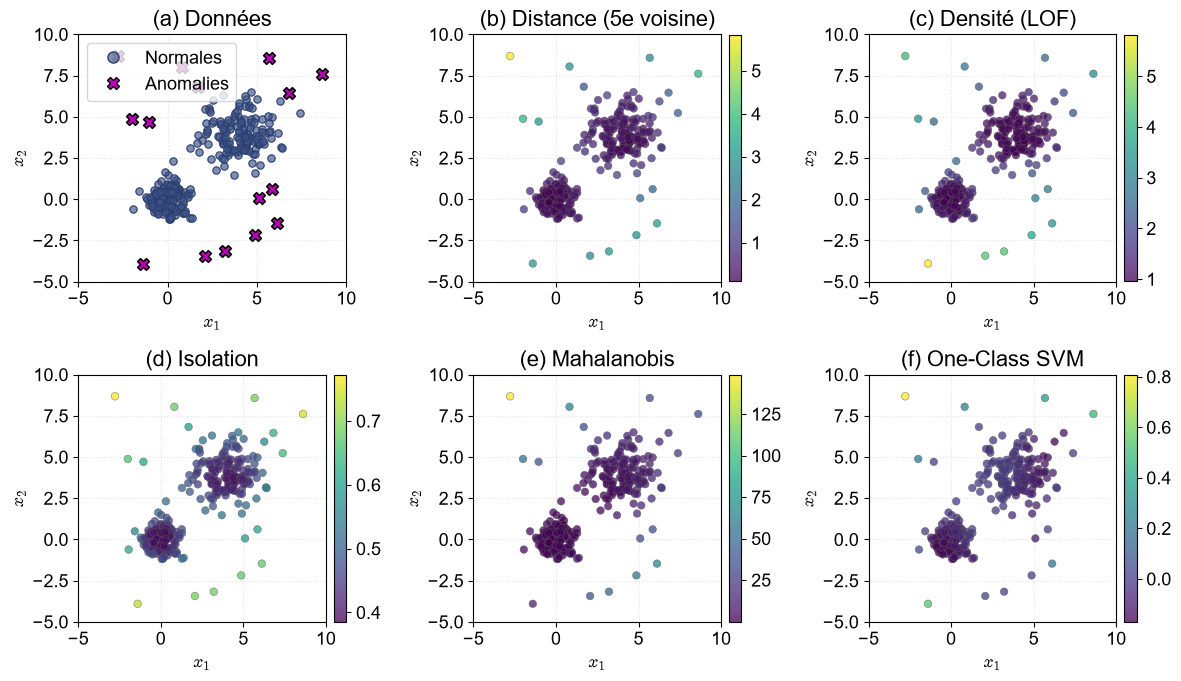

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()

# Panneau (a) : les données, anomalies mises en évidence
ax = axes[0]
ax.scatter(X2[vrai == 0, 0], X2[vrai == 0, 1], s=28,
           color=to_rgba(BLEU, 0.65), edgecolors=BORD[BLEU],
           linewidths=0.8, zorder=3)
ax.scatter(X2[vrai == 1, 0], X2[vrai == 1, 1], s=70, color=MAGENTA,
           edgecolors='black', linewidths=1.2, marker='X', zorder=4)
ax.set_title("(a) Données")
ax.legend(handles=[
    Line2D([], [], marker='o', ls='', markerfacecolor=to_rgba(BLEU, 0.65),
           markeredgecolor=BORD[BLEU], markersize=8, label='Normales'),
    Line2D([], [], marker='X', ls='', markerfacecolor=MAGENTA,
           markeredgecolor='black', markersize=9, label='Anomalies')])

titres = ['(b) Distance (5e voisine)', '(c) Densité (LOF)', "(d) Isolation",
          '(e) Mahalanobis', '(f) One-Class SVM']

for ax, s, titre in zip(axes[1:], [s_dist, s_lof, s_iso, s_maha, s_svm],
                        titres):
    nuage = ax.scatter(X2[:, 0], X2[:, 1], c=s, cmap='viridis', s=30, alpha=0.75,
                       edgecolors='0.35', linewidths=0.4, zorder=3)
    cb = fig.colorbar(nuage, ax=ax, fraction=0.046, pad=0.03)
    ax.set_title(titre)

for ax in axes:
    ax.set_xlim(-5, 10)
    ax.set_ylim(-5, 10)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.grid(alpha=0.35, linestyle=':', zorder=0)

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap14_CinqFamilles')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 14.7 : Préparation du jeu <i>Breast Cancer</i> avec tumeurs malignes rares</h3>

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

donnees = load_breast_cancer()
Xb, yb = donnees.data, donnees.target   # 0 = maligne, 1 = bénigne

rng = np.random.default_rng(42)

# Conserver les 357 bénignes et tirer 20 malignes
X_benignes = Xb[yb == 1]
X_malignes = rng.choice(Xb[yb == 0], size=20, replace=False, axis=0)

# Construire le jeu de détection d'anomalies
X_a_brut = np.vstack([X_benignes, X_malignes])
y_a = np.r_[np.zeros(len(X_benignes), dtype=int),
            np.ones(len(X_malignes), dtype=int)]

X_a = StandardScaler().fit_transform(X_a_brut)

print(f"{len(y_a)} observations, {y_a.sum()} anomalies ({y_a.mean():.3f})")

377 observations, 20 anomalies (0.053)


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 14.8 : Reconstruction par ACP : aberrances contre nouveautés</h3>

In [12]:
from sklearn.decomposition import PCA
from sklearn.metrics import average_precision_score, roc_auc_score

def erreur_acp(Xd, q=3):
    """Erreur de reconstruction d'une ACP à q composantes."""
    acp = PCA(n_components=q).fit(Xd)
    reconstruction = acp.inverse_transform(acp.transform(Xd))
    return np.sum((Xd - reconstruction) ** 2, axis=1)

# Cadre des aberrances : standardisation et ACP ajustées sur tout le jeu
e_toutes = erreur_acp(X_a, q=3)

# Cadre des nouveautés : standardisation et ACP ajustées sur les normales
scaler_n = StandardScaler().fit(X_a_brut[y_a == 0])
X_a_n = scaler_n.transform(X_a_brut)

acp_n = PCA(n_components=3).fit(X_a_n[y_a == 0])
reconstruction_n = acp_n.inverse_transform(acp_n.transform(X_a_n))
e_normales = np.sum((X_a_n - reconstruction_n) ** 2, axis=1)

# Résultats de l'erreur de reconstruction
ap_toutes = average_precision_score(y_a, e_toutes)
ap_normales = average_precision_score(y_a, e_normales)

Z = PCA(n_components=3).fit_transform(X_a)
auc_orientees = []

for j in range(3):
    auc = roc_auc_score(y_a, Z[:, j])
    auc_orientees.append(max(auc, 1 - auc))

# --- Affichage ---
titre = "Résultats de l'ACP"
L = max(62, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Analyse':<34}{'Métrique':<20}{'Valeur':>8}")
print("-" * L)

print(f"{'ACP ajustée sur tout le jeu':<34}{'AP':<20}{ap_toutes:>8.3f}")
print(f"{'ACP ajustée sur les normales':<34}{'AP':<20}{ap_normales:>8.3f}")

for j, auc in enumerate(auc_orientees, start=1):
    print(f"{f'Composante {j} seule':<34}{'ROC-AUC orientée':<20}{auc:>8.3f}")

print("=" * L)

Résultats de l'ACP
Analyse                           Métrique              Valeur
--------------------------------------------------------------
ACP ajustée sur tout le jeu       AP                     0.170
ACP ajustée sur les normales      AP                     0.598
Composante 1 seule                ROC-AUC orientée       0.978
Composante 2 seule                ROC-AUC orientée       0.738
Composante 3 seule                ROC-AUC orientée       0.531


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 14.9 : Détection de nouveautés : scorer des observations nouvelles</h3>

In [13]:
from sklearn.model_selection import train_test_split

# Séparer aléatoirement les observations normales
X_app_brut, X_norm_test_brut = train_test_split(X_benignes, train_size=300, 
                                                random_state=42)

# Construire l'ensemble de test : 57 normales et 20 anomalies
X_test_brut = np.vstack([X_norm_test_brut, X_malignes])
y_test = np.r_[np.zeros(len(X_norm_test_brut), dtype=int),
               np.ones(len(X_malignes), dtype=int)]

# Ajuster la standardisation uniquement sur les normales d'apprentissage
scaler_app = StandardScaler().fit(X_app_brut)
X_app = scaler_app.transform(X_app_brut)
X_test = scaler_app.transform(X_test_brut)

# LOF exige novelty=True pour accepter de nouvelles observations
lof_n = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(X_app)
s_lof_n = -lof_n.score_samples(X_test)

# La forêt d'isolation le fait nativement
iso_n = IsolationForest(n_estimators=200, random_state=42).fit(X_app)
s_iso_n = -iso_n.score_samples(X_test)

# Précision moyenne obtenue par chaque détecteur sur l'ensemble de test
ap_lof = average_precision_score(y_test, s_lof_n)
ap_iso = average_precision_score(y_test, s_iso_n)

# --- Affichage ---
titre = "Détection de nouveautés"
L = max(54, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"Ensemble de test : {len(y_test)} observations, "
      f"dont {int(y_test.sum())} anomalies")
print("-" * L)
print(f"{'Méthode':<44}{'AP':>10}")
print("-" * L)
print(f"{'LOF (novelty=True)':<44}{ap_lof:>10.3f}")
print(f"{'Forêt d\'isolation':<44}{ap_iso:>10.3f}")
print("=" * L)


Détection de nouveautés
Ensemble de test : 77 observations, dont 20 anomalies
------------------------------------------------------
Méthode                                             AP
------------------------------------------------------
LOF (novelty=True)                               0.865
Forêt d'isolation                                0.909


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 14.10 : Comparaison des familles par la précision moyenne</h3>

In [14]:
scores = {
    'Distance k-PPV': NearestNeighbors(n_neighbors=5)
        .fit(X_a).kneighbors()[0][:, -1],
    'LOF': -LocalOutlierFactor(n_neighbors=20)
        .fit(X_a).negative_outlier_factor_,
    "Forêt d'isolation": -IsolationForest(n_estimators=200, random_state=42)
        .fit(X_a).score_samples(X_a),
    'Enveloppe elliptique': EllipticEnvelope(contamination=0.05, support_fraction=0.9, random_state=42)
        .fit(X_a).mahalanobis(X_a),
    'One-Class SVM': -OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
        .fit(X_a).decision_function(X_a),
    'Reconstruction ACP': erreur_acp(X_a, q=3),
}

# Précision moyenne obtenue par chaque détecteur sur le jeu complet
ap_scores = {
    nom: average_precision_score(y_a, score)
    for nom, score in scores.items()
}

# --- Affichage ---
L = 35
print("=" * L)
print(f"{'Méthode':<25}{'AP':>10}")
print("-" * L)
for nom, ap in ap_scores.items():
    print(f"{nom:<25}{ap:>10.3f}")
print("=" * L)

Méthode                          AP
-----------------------------------
Distance k-PPV                0.431
LOF                           0.473
Forêt d'isolation             0.626
Enveloppe elliptique          0.572
One-Class SVM                 0.233
Reconstruction ACP            0.170


<h3><span style="font-size: 30px">&#127924;</span> Figure : Courbes précision-rappel</h3>

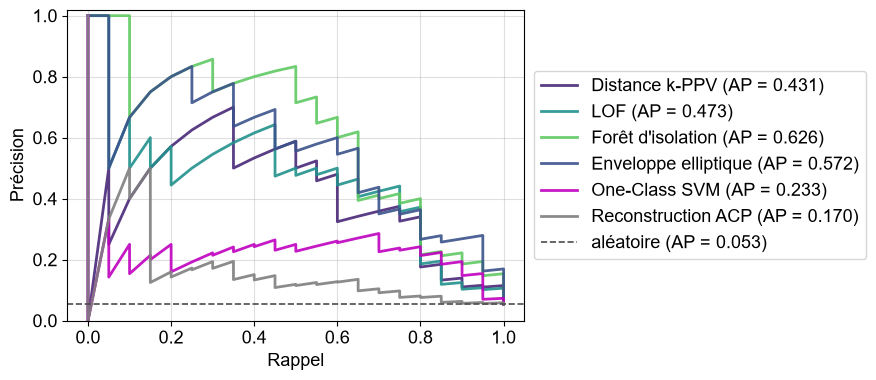

In [15]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(9, 4))

couleurs = PALETTE + ['#7f7f7f']
for (nom, s), coul in zip(scores.items(), couleurs):
    p, r, _ = precision_recall_curve(y_a, s)
    ap = average_precision_score(y_a, s)
    ax.plot(r, p, color=coul, linewidth=2, alpha=0.9,
            label=f"{nom} (AP = {ap:.3f})")
ax.axhline(y_a.mean(), color='0.3', linestyle='--', linewidth=1.2,
           label=f"aléatoire (AP = {y_a.mean():.3f})")
ax.set_xlabel("Rappel")
ax.set_ylabel("Précision")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.4, zorder=0)
# Légende à l'extérieur, à droite des axes, alignée sur le haut
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap14_PR')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 14.11 : Aire sous la courbe ROC contre précision moyenne</h3>

In [16]:
L = 48
print("=" * L)
print(f"{'Méthode':<24}{'ROC-AUC':>12}{'AP':>12}")
print("-" * L)

for nom, score in scores.items():
    auc = roc_auc_score(y_a, score)
    ap = average_precision_score(y_a, score)
    print(f"{nom:<24}{auc:>12.3f}{ap:>12.3f}")

print("=" * L)

Méthode                      ROC-AUC          AP
------------------------------------------------
Distance k-PPV                 0.908       0.431
LOF                            0.907       0.473
Forêt d'isolation              0.943       0.626
Enveloppe elliptique           0.949       0.572
One-Class SVM                  0.874       0.233
Reconstruction ACP             0.714       0.170


<h3><span style="font-size: 30px">&#127924;</span> Figure : ROC et précision-rappel côte à côte</h3>

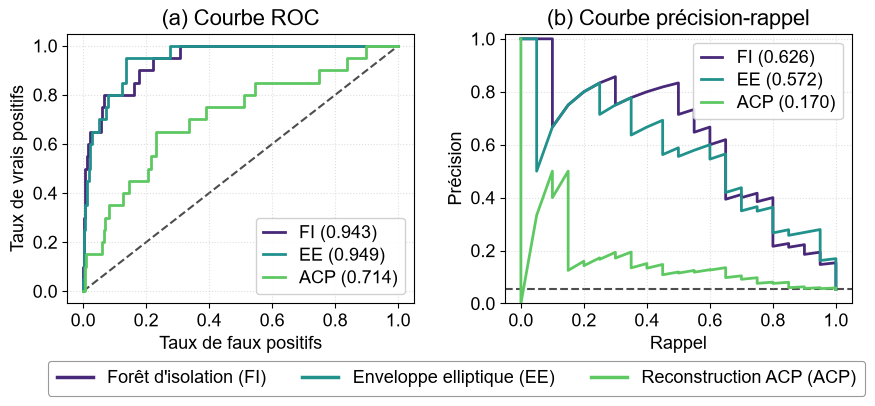

In [17]:
from sklearn.metrics import roc_curve, precision_recall_curve
from matplotlib.lines import Line2D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.5, 4),
                               layout='constrained')

choix  = ["Forêt d'isolation", 'Enveloppe elliptique', 'Reconstruction ACP']
abrevs = ['FI', 'EE', 'ACP']
coul   = [VIOLET, SARCELLE, VERT]

for nom, ab, c in zip(choix, abrevs, coul):
    s = scores[nom]
    fpr, tpr, _ = roc_curve(y_a, s)
    ax1.plot(fpr, tpr, color=c, linewidth=2,
             label=f"{ab} ({roc_auc_score(y_a, s):.3f})")
    p, r, _ = precision_recall_curve(y_a, s)
    ax2.plot(r, p, color=c, linewidth=2,
             label=f"{ab} ({average_precision_score(y_a, s):.3f})")

ax1.plot([0, 1], [0, 1], color='0.3', linestyle='--', linewidth=1.5, zorder=1)
ax1.set_xlabel("Taux de faux positifs")
ax1.set_ylabel("Taux de vrais positifs")
ax1.set_title("(a) Courbe ROC")

ax2.axhline(y_a.mean(), color='0.3', linestyle='--', linewidth=1.5, zorder=1)
ax2.set_xlabel("Rappel")
ax2.set_ylabel("Précision")
ax2.set_ylim(0, 1.02)
ax2.set_title("(b) Courbe précision-rappel")

for ax in (ax1, ax2):
    ax.grid(alpha=0.4, linestyle=':', zorder=0)

# Légendes internes courtes : abréviation + valeur
style_leg = dict(handlelength=1.2, borderpad=0.4,
                 labelspacing=0.3, framealpha=0.9)
ax1.legend(loc='lower right', **style_leg)
ax2.legend(loc='upper right', **style_leg)

# Légende globale : 1 ligne, 3 colonnes, nom complet (abréviation), encadrée
poignees = [Line2D([0], [0], color=c, linewidth=2.5) for c in coul]
etiquettes = [f"{nom} ({ab})" for nom, ab in zip(choix, abrevs)]
leg = fig.legend(poignees, etiquettes, loc='outside lower center',
                 ncol=3, bbox_to_anchor=(0.53, 0),
                 frameon=True, fancybox=True,
                 edgecolor='0.6', facecolor='white', framealpha=1,
                 borderpad=0.5, handlelength=2, columnspacing=2)
leg.get_frame().set_linewidth(0.8)

# Réserver une bande en bas pour la légende et espacer les deux graphiques
fig.get_layout_engine().set(rect=(0, 0.12, 1, 0.88),
                            wspace=0.08)
# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap14_RocPR')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 14.12 : Précision et rappel au rang <i>k</i></h3>

In [18]:
# Scores de la forêt d'isolation
s_iso_a = scores["Forêt d'isolation"]

# Classer les observations de la plus suspecte à la plus normale
ordre = np.argsort(-s_iso_a)

# Calculer la précision et le rappel aux différents rangs
resultats_rang_k = []

for k in [10, 20, 50, 100]:
    selection = ordre[:k]
    precision_k = y_a[selection].mean()
    rappel_k = y_a[selection].sum() / y_a.sum()
    resultats_rang_k.append((k, precision_k, rappel_k))

# --- Affichage ---
L = 54
print("=" * L)
print(f"{'k':<8}{'Précision au rang k':>23}{'Rappel au rang k':>23}")
print("-" * L)
for k, precision_k, rappel_k in resultats_rang_k:
    print(f"{k:<8}{precision_k:>23.3f}{rappel_k:>23.3f}")
print("=" * L)

k           Précision au rang k       Rappel au rang k
------------------------------------------------------
10                        0.800                  0.400
20                        0.600                  0.600
50                        0.320                  0.800
100                       0.190                  0.950


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 14.13 : Anomalies contextuelles et collectives dans une série temporelle</h3>

In [19]:
rng_t = np.random.default_rng(0)
jours = np.arange(365)

# Signal saisonnier bruité
saison = 12 + 10 * np.sin(2 * np.pi * (jours - 100) / 365)
temperature = saison + rng_t.normal(0, 1.2, 365)

temperature[15] = 26.0                       # anomalie contextuelle
temperature[200:213] = temperature[199]      # anomalie collective

# Score ponctuel global : le score z sur les valeurs brutes
z_global = (temperature - temperature.mean()) / temperature.std()

# Score contextuel : le score z sur les résidus du modèle saisonnier
residus = temperature - saison
z_residu = (residus - residus.mean()) / residus.std()

# Score collectif : écart-type sur une fenêtre glissante de sept jours
ecart_glissant = pd.Series(temperature).rolling(7).std().values

# Résultats du score global
nb_depassements = int((np.abs(z_global) > 3).sum())

# Résultats du score contextuel
indices_contextuels = np.where(np.abs(z_residu) > 3)[0]

# Résultats du score collectif
indices_collectifs = np.where(ecart_glissant < 0.1)[0]

# --- Affichage ---
L =78
print("=" * L)
print(f"{'Analyse':<48}{'Résultat':>30}")
print("-" * L)
print(f"{'Plage des températures':<48}{f'{temperature.min():.1f} à {temperature.max():.1f} °C':>30}")
print(f"{'Globale : score z à l\'indice 15':<48}{z_global[15]:>30.2f}")
print(f"{'Globale : nombre de |z| > 3':<48}{nb_depassements:>30}")
print(f"{'Contextuelle : score z du résidu à l\'indice 15':<48}{z_residu[15]:>30.2f}")
print(f"{'Contextuelle : indices signalés':<48}{str(indices_contextuels):>30}")
print(f"{'Collective : indices signalés':<45}{str(indices_collectifs):>30}")

print("=" * L)

Analyse                                                               Résultat
------------------------------------------------------------------------------
Plage des températures                                          -0.8 à 26.0 °C
Globale : score z à l'indice 15                                           1.94
Globale : nombre de |z| > 3                                                  0
Contextuelle : score z du résidu à l'indice 15                           13.75
Contextuelle : indices signalés                                           [15]
Collective : indices signalés                [205 206 207 208 209 210 211 212]


<h3><span style="font-size: 30px">&#127924;</span> Figure : Anomalies contextuelles et collectives</h3>

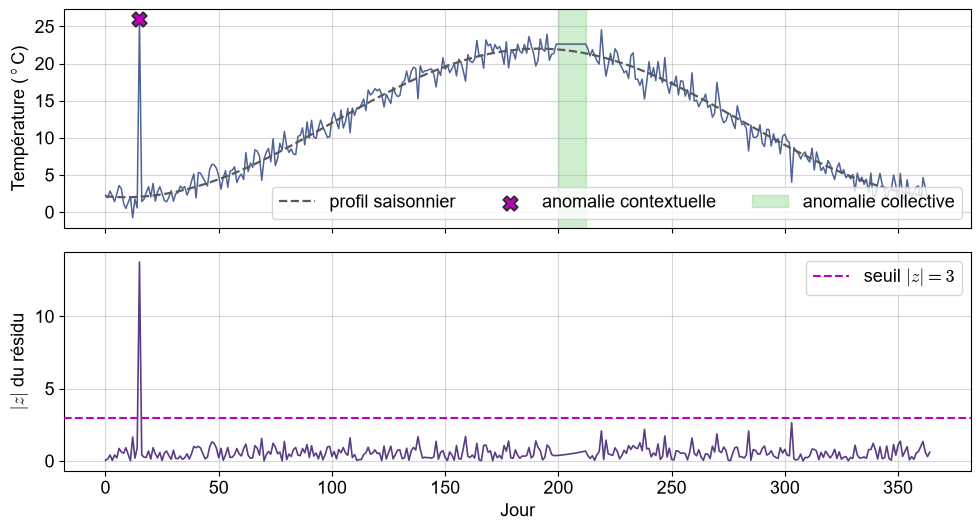

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)

ax1.plot(jours, temperature, color=BLEU, linewidth=1.1, alpha=0.9, zorder=3)
ax1.plot(jours, saison, color='0.35', linestyle='--', linewidth=1.6, zorder=4,
         label='profil saisonnier')
ax1.scatter([15], [temperature[15]], s=110, marker='X', c=MAGENTA,
            edgecolors='0.15', linewidths=1.2, zorder=5,
            label='anomalie contextuelle')
ax1.axvspan(200, 212, color=VERT, alpha=0.30, zorder=1,
            label='anomalie collective')
ax1.set_ylabel("Température ($^\\circ$C)")
ax1.legend(loc='lower right', ncol=3)

ax2.plot(jours, np.abs(z_residu), color=VIOLET, linewidth=1.2, alpha=0.9, zorder=3)
ax2.axhline(3, color=MAGENTA, linestyle='--', linewidth=1.5, zorder=4,
            label='seuil $|z| = 3$')
ax2.set_xlabel("Jour")
ax2.set_ylabel("$|z|$ du résidu")
ax2.legend(loc='upper right')

for ax in (ax1, ax2):
    ax.grid(alpha=0.5, zorder=0)

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap14_SerieTemporelle')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 14.14 : Explication SHAP du score d'isolation</h3>

In [21]:
import shap

foret = IsolationForest(n_estimators=200, random_state=42).fit(X_a)
np.random.seed(42)
explicateur_iso = shap.KernelExplainer(
    lambda z: -foret.score_samples(z),
    shap.sample(X_a, 60, random_state=42))

# L'anomalie au score d'isolation le plus élevé
scores_iso = -foret.score_samples(X_a)
i_anom = int(np.argmax(np.where(y_a == 1, scores_iso, -np.inf)))

valeurs = explicateur_iso.shap_values(X_a[i_anom:i_anom + 1],
                                      nsamples=200, silent=True)
contributions = (pd.Series(np.asarray(valeurs).ravel(),
                           index=donnees.feature_names)
                 .sort_values(key=abs, ascending=False))
print(contributions.head(5).round(4).to_string())

area error             0.0451
worst area             0.0316
mean radius            0.0313
radius error           0.0283
mean concave points    0.0252


<h3><span style="font-size: 30px">&#127924;</span> Figure : Contributions SHAP au score d'isolation</h3>

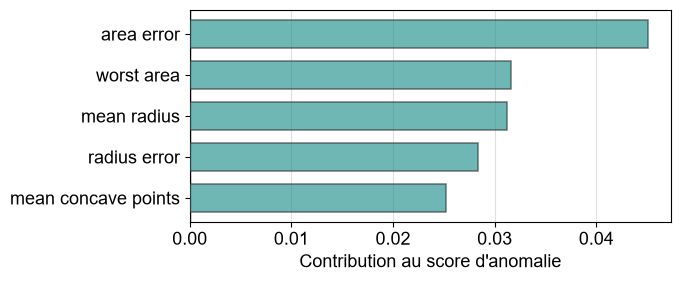

In [22]:
cinq = contributions.head(5)[::-1]
coul = [SARCELLE if v > 0 else VIOLET for v in cinq.values]

fig, ax = plt.subplots(figsize=(7, 3))

ax.barh(range(len(cinq)), cinq.values, color=coul, alpha=0.65,
        edgecolor='0.2', height=0.7, linewidth=1.1, zorder=3)
ax.set_yticks(range(len(cinq)))
ax.set_yticklabels(cinq.index)
ax.axvline(0, color='0.2', linewidth=1)
ax.set_xlabel("Contribution au score d'anomalie")
ax.grid(axis='x', alpha=0.4, zorder=0)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap14_ShapAnomalie')

plt.show()

<hr style='border-top:4px solid #1F77B4;'>